# exercise 4: C alpha distance histogram

In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
import gzip
import matplotlib.pyplot as plt

In [5]:
data_dir = '/content/drive/MyDrive/4. ML DL archive/0. 생명정보학 및 신약 개발 개념 노트/LAIDD 신약 개발 강의 노트/중급 강의 노트/단백질 구조 기반 약물탐색/2. PDB 분석/practice_3/pisces/pdb'
list_file = data_dir + '/list.txt'
pdb_list = [x.strip().split() for x in open(list_file)]

In [15]:
main_atom_list = [' N  ', ' CA ', ' C  ', ' O  ']
Res31 = {'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F',
         'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L',
         'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R',
         'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y', }
res_list = Res31.keys()

In [16]:
def read_pdb(pdb_file):
    fp = gzip.open(pdb_file)
    lines = fp.readlines()
    fp.close()
    chain_dict = dict()
    atom_coor_dict = dict()

    check_m = False
    modres_dict = dict()
    for line_b in lines:
        line = line_b.decode('ascii')
        if line[0:10] == 'REMARK 465':
            if line[15:27] == 'RES C SSSEQI':
                check_m = True
                continue
            if check_m:
                res_name3 = line[15:18]
                res_inser = line[22:27]
                chain_id = line[19]
                if chain_id not in chain_dict:
                    chain_dict[chain_id] = dict()
                    atom_coor_dict[chain_id] = dict()
                chain_dict[chain_id][res_inser] = res_name3
                atom_coor_dict[chain_id][res_inser] = dict()

        elif line[0:6] == 'MODRES':
            res_name3_mod = line[12:15]
            res_name3 = line[24:27]
            if res_name3_mod not in modres_dict and res_name3 in Res31:
                modres_dict[res_name3_mod] = res_name3

        elif line[0:6] == 'ATOM  ':
            chain_id = line[21]
            res_name3 = line[17:20]
            res_inser = line[22:27]

            alt_loc = line[16]
            if alt_loc != ' ' and alt_loc != 'A':
                continue

            if chain_id not in chain_dict:
                chain_dict[chain_id] = dict()
                atom_coor_dict[chain_id] = dict()
            if res_name3 not in Res31:
                continue
            if res_inser not in chain_dict[chain_id]:
                chain_dict[chain_id][res_inser] = res_name3
                atom_coor_dict[chain_id][res_inser] = dict()

            atom_name = line[12:16]

            if atom_name in main_atom_list:
                coor = (line[30:38], line[38:46], line[46:54])
                coor = np.array(coor, dtype=np.float64)
                atom_coor_dict[chain_id][res_inser][atom_name] = coor

        elif line[0:6] == 'HETATM':
            chain_id = line[21]
            res_name3 = line[17:20]
            res_inser = line[22:27]
            alt_loc = line[16]
            if alt_loc != ' ' and alt_loc != 'A':
                continue

            if chain_id not in chain_dict:
                chain_dict[chain_id] = dict()
                atom_coor_dict[chain_id] = dict()
            if res_name3 not in modres_dict:
                continue

            if res_inser not in chain_dict[chain_id]:
                chain_dict[chain_id][res_inser] = res_name3
                atom_coor_dict[chain_id][res_inser] = dict()

            atom_name = line[12:16]
            if atom_name in main_atom_list:
                coor = (line[30:38], line[38:46], line[46:54])
                coor = np.array(coor, dtype=np.float64)
                atom_coor_dict[chain_id][res_inser][atom_name] = coor

    return chain_dict, atom_coor_dict, modres_dict

def cal_single(chain_dict, atom_coor_dict, modres_dict, chain_id, ca_dist_dict):
    keys = sorted(chain_dict[chain_id].keys())
    num_keys = len(keys)
    for i in range(num_keys):

        key = keys[i]
        res_name = chain_dict[chain_id][key]
        if res_name in modres_dict:
            res_name = modres_dict[res_name]

        res_dict = atom_coor_dict[chain_id][key]
        if ' CA ' in res_dict:
            pos_ca = res_dict[' CA ']
        else:
            continue
        for j in range(1,6):
            if i+j <= num_keys-1:
                key_j = keys[i+j]
            else:
                continue
            res_j_dict = atom_coor_dict[chain_id][key_j]
            if ' CA ' in res_j_dict:
                pos_j_ca = res_j_dict[' CA ']
                dist = np.linalg.norm(pos_ca - pos_j_ca)
                ca_dist_dict[j] += [dist]

다운로드 실패 4V4M: HTTP Error 404: Not Found
다운로드 실패 6TAK: HTTP Error 404: Not Found
다운로드 실패 6TN5: HTTP Error 404: Not Found
다운로드 실패 6TWO: HTTP Error 404: Not Found
다운로드 실패 6XY7: HTTP Error 404: Not Found
다운로드 실패 7AF2: HTTP Error 404: Not Found
다운로드 실패 7AVC: HTTP Error 404: Not Found
다운로드 실패 7B6A: HTTP Error 404: Not Found
다운로드 실패 7M1A: HTTP Error 404: Not Found
다운로드 실패 7NQG: HTTP Error 404: Not Found
다운로드 실패 7NZD: HTTP Error 404: Not Found
다운로드 실패 7OLW: HTTP Error 404: Not Found
다운로드 실패 7OMV: HTTP Error 404: Not Found
다운로드 실패 7OS5: HTTP Error 404: Not Found
다운로드 실패 7OST: HTTP Error 404: Not Found
다운로드 실패 7P24: HTTP Error 404: Not Found
다운로드 실패 7P5R: HTTP Error 404: Not Found
다운로드 실패 7PJ4: HTTP Error 404: Not Found
다운로드 실패 7Q4T: HTTP Error 404: Not Found
다운로드 실패 7QYM: HTTP Error 404: Not Found
다운로드 실패 7QYM: HTTP Error 404: Not Found


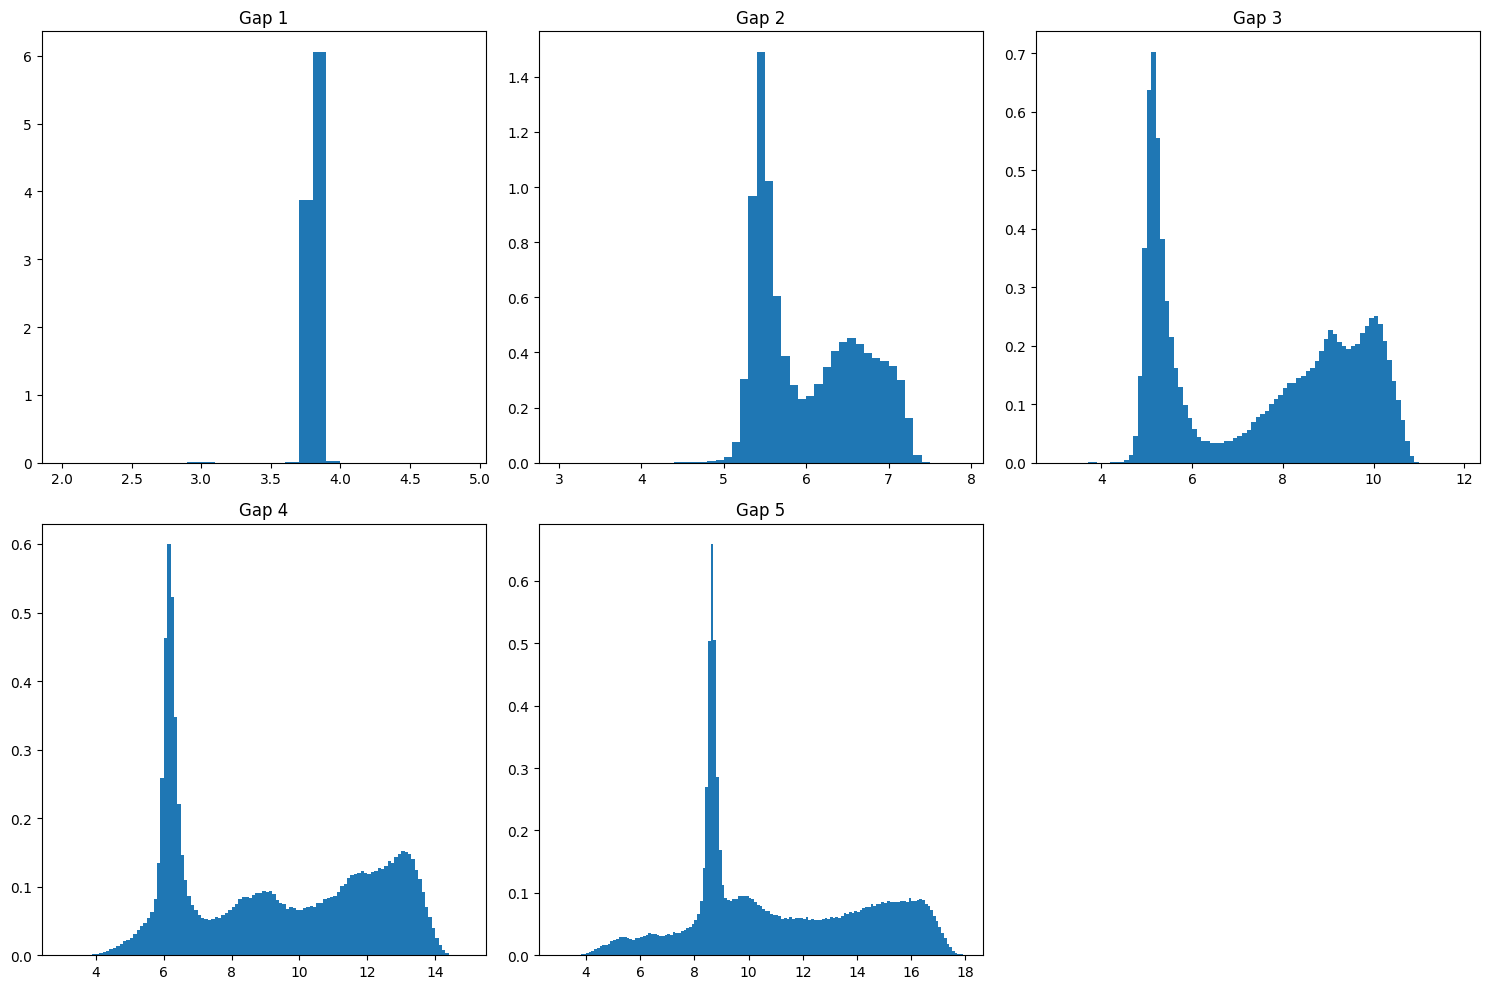

In [17]:
ca_dist_dict = dict()
for j in range(1,6):
    ca_dist_dict[j] = list()

num_pdb = len(pdb_list)
for i in range(0, num_pdb):
    pdb_id = pdb_list[i][0]
    chain_id = pdb_list[i][1]

    # 1. 자동 폴더 생성 및 다운로드
    sub_dir = '%s/%s' % (data_dir, pdb_id[0])
    pdb_file = '%s/%s.pdb.gz' % (sub_dir, pdb_id)

    if not os.path.exists(sub_dir):
        os.makedirs(sub_dir, exist_ok=True)

    if not os.path.exists(pdb_file):
        url = f'https://files.rcsb.org/download/{pdb_id}.pdb.gz'
        try:
            urllib.request.urlretrieve(url, pdb_file)
        except Exception as e:
            print(f'다운로드 실패 {pdb_id}: {e}')
            continue

    chain_dict, atom_coor_dict, modres_dict = read_pdb(pdb_file)

    # 2. 사슬 불일치(KeyError) 방지
    if chain_id not in chain_dict:
        continue

    cal_single(chain_dict, atom_coor_dict, modres_dict, chain_id, ca_dist_dict)

# 출력 결과물이 한눈에 보이도록 레이아웃 수정
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
bins = np.arange(2,5,0.1)
plt.hist(ca_dist_dict[1], bins, density=True)
plt.title("Gap 1")

plt.subplot(2, 3, 2)
bins = np.arange(3,8,0.1)
plt.hist(ca_dist_dict[2], bins, density=True)
plt.title("Gap 2")

plt.subplot(2, 3, 3)
bins = np.arange(3,12,0.1)
plt.hist(ca_dist_dict[3], bins, density=True)
plt.title("Gap 3")

plt.subplot(2, 3, 4)
bins = np.arange(3,15,0.1)
plt.hist(ca_dist_dict[4], bins, density=True)
plt.title("Gap 4")

plt.subplot(2, 3, 5)
bins = np.arange(3,18,0.1)
plt.hist(ca_dist_dict[5], bins, density=True)
plt.title("Gap 5")

plt.tight_layout()
plt.show()

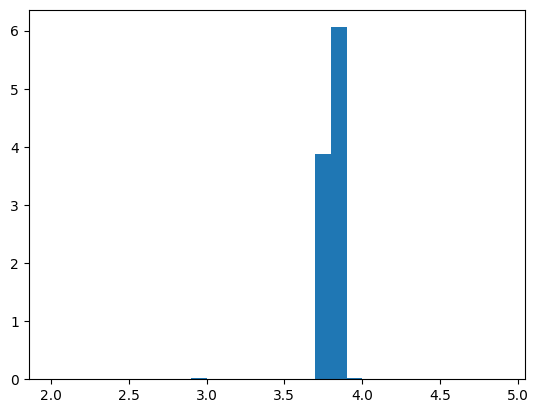

In [19]:
bins = np.arange(2,5,0.1)
a = plt.hist(ca_dist_dict[1], bins, density=True)

인접한 두 아미노산($i$와 $i+1$) 알파 탄소(Cα) 간의 거리 분포입니다. 3.8 Å 부근에서 단일하고 날카로운 봉우리가 나타납니다. 이는 단백질 뼈대를 구성하는 펩타이드 결합이 이중 결합과 같은 물리적 특성을 가져 회전이 불가능하고 팽팽한 평면 구조(주로 trans 이성질체)로 단단히 고정되어 있기 때문입니다. 3.0 Å 부근에 아주 미세하게 나타나는 흔적은 극히 드문 cis 결합 구조를 의미합니다.

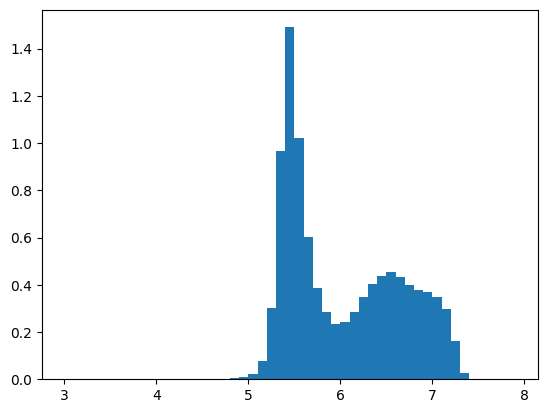

In [20]:
bins = np.arange(3,8,0.1)
a2 = plt.hist(ca_dist_dict[2], bins, density=True)

두 칸 떨어진 잔기($i$와 $i+2$)의 거리 분포입니다. 거리가 짧은 쪽(~ 5.4 Å)과 긴 쪽(~6.5 Å 이상)으로 산봉우리가 두 개로 갈라지기 시작(Bimodal distribution)합니다. 이는 아미노산 사슬이 공간상에서 어떻게 꺾이느냐에 따른 2차 구조의 차이입니다. 왼쪽의 짧은 봉우리는 사슬이 둥글게 말리는 알파 나선(Alpha-helix) 구조의 뼈대를, 오른쪽의 넓은 봉우리는 길게 뻗어 나가는 베타 병풍(Beta-strand) 구조를 나타냅니다. (beta-strand -> beta-sheet)

베타 병풍(Beta-sheet)은 알파 나선처럼 고정된 짧은 간격($n$) 하나로 특정할 수 없습니다. 알파 나선이 서열이 인접한 잔기들끼리 촘촘하게 감기는 근거리 상호작용이라면, 베타 병풍은 서열상으로 멀리 떨어진 뼈대 구간들이 3차원 공간에서 나란히 마주쳐 수소 결합을 맺는 원거리 상호작용(Long-range interaction)이기 때문입니다.이를 두 가지 관점으로 나누어 확인할 수 있습니다.

<br>

*   단일 가닥이 뻗어 있는 형태 확인 (n=2): 베타 병풍을 구성하는 낱개의 줄기를 '베타 가닥(Beta-strand)'이라고 합니다. 가닥 하나가 지그재그 형태로 팽팽하게 펴진 구조적 특징은 $i$와 $i+2$ (n=2) 간격에서 가장 잘 드러납니다. 앞서 해석한 Gap 2 히스토그램에서 약 6.5~7.0Å 부근에 넓게 형성된 오른쪽 산봉우리가 바로 곧게 펴져 있는 베타 가닥의 Cα 거리를 의미합니다.

<br>

*   병풍 구조의 완성 (가변적이고 먼 간격, n > 10~ 100+): 뻗어 있는 여러 베타 가닥이 옆으로 들러붙어 실제 '병풍' 모양을 완성하는 수소 결합은 $i$번째 잔기와 서열 번호가 수십~ 수백 개 떨어져 있는 잔기 사이에서 불규칙하게 형성됩니다. 가닥의 진행 방향이 평행(Parallel)인지 역평행(Anti-parallel)인지에 따라 짝을 맺는 규칙도 달라지므로 특정 $n$값을 기준 삼을 수 없습니다.따라서 알파 탄소 거리를 통해 베타 병풍을 구조적으로 판별할 때는, 짧은 서열 간격($n=2$)으로 뼈대가 곧게 펴진(Extended) 구간들을 먼저 찾습니다. 그 후, 해당 구간들이 서열 번호($n$)와 무관하게 3차원 공간상에서 약 4.0~5.0Å 이내로 나란히 인접해 있는지를 전체 단백질의 2차원 거리 행렬(Distance matrix)을 훑어보며 교차 검증하게 됩니다.

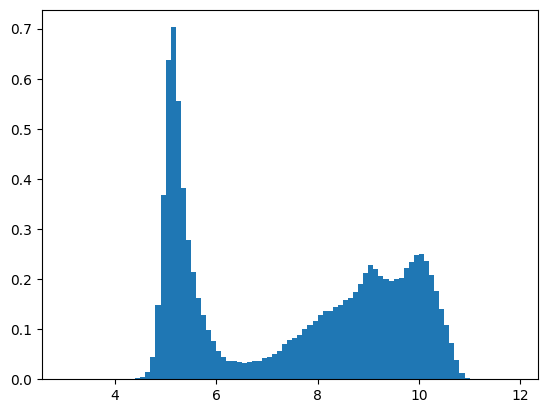

In [21]:
bins = np.arange(3,12,0.1)
a3 = plt.hist(ca_dist_dict[3], bins, density=True)

세 칸 떨어진 잔기($i$와 $i+3$)의 거리입니다. 5.0 ~ 5.5 Å 부근의 좁고 높은 피크와 9~10 Å 부근의 넓은 분포로 극명하게 나뉩니다. 알파 나선은 한 바퀴 회전하는 데 정확히 3.6개의 아미노산 잔기가 필요합니다. 따라서 $i$번째와 $i+3$번째 아미노산은 3D 공간상에서 나선의 같은 축을 향해 가깝게 마주 보게 되므로 저렇게 강력하고 예리한 알파 나선의 시그널을 형성합니다.

*   i 와 i+3 (n=3): 3D 공간상의 최단 근접성

알파 나선은 한 바퀴를 회전하는 데 평균 3.6개의 아미노산 잔기가 필요합니다. 따라서 원통형 나선의 구조상 i번째와 i+3번째 아미노산은 나선의 같은 쪽 면을 향해 나란히 배열되므로 물리적 거리가 약 5.0~5.5Å으로 매우 가깝습니다. 또한, 일반적인 알파 나선보다 조금 더 조밀하게 말린 '$3_{10}$ 나선($3_{10}$-helix)' 구조를 판별하는 직접적인 기준이 됩니다.

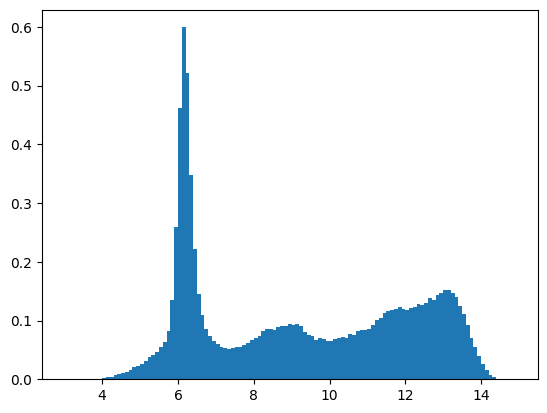

In [22]:
bins = np.arange(3,15,0.1)
a4 = plt.hist(ca_dist_dict[4], bins, density=True)

네 칸 떨어진 잔기($i$와 $i+4$)의 거리입니다. 알파 나선이 정확히 한 바퀴를 돌아 $i$번째 바로 위층에 $i+4$번째 아미노산이 위치하게 되면서, 6.0 ~ 6.5 Å 부근에서 나선의 수직 피치(Pitch) 거리를 나타내는 뾰족한 봉우리가 생성됩니다. 뻗어 있는 베타 구조나 무작위 코일 구조들은 거리가 멀어지며 12~14 Å까지 넓게 퍼진 형태를 보입니다.

*   i 와 i+4 (n=4): 수소 결합의 주기와 나선의 수직 높이(Pitch)

단백질의 전형적인 알파 나선을 뼈대째로 단단하게 묶어주는 수소 결합(Hydrogen bond)은 항상 i번째 잔기의 카보닐 산소(C=O)와 i+4번째 잔기의 아미드 질소(N-H) 사이에 형성됩니다. 이때 측정되는 약 6.0~6.5Å의 Cα 거리는 나선이 정확히 한 바퀴를 완성하여 쌓아 올려진 1층(1 Turn)의 수직 높이를 의미합니다.

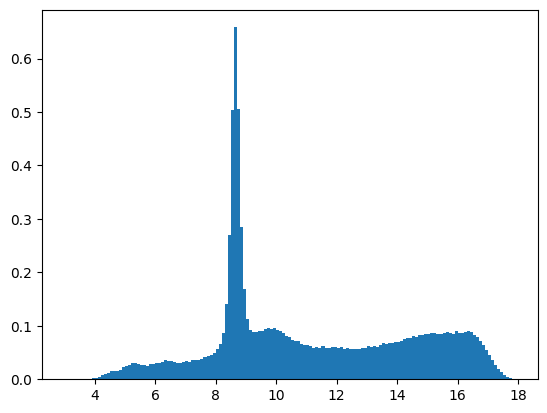

In [23]:
bins = np.arange(3,18,0.1)
a5 = plt.hist(ca_dist_dict[5], bins, density=True)

다섯 칸 떨어진 잔기($i$와 $i+5$)의 거리입니다. 알파 나선의 구조적 규칙성이 이어져 8.5~9.0 Å 부근에 여전히 피크가 존재하지만, 서열 간격이 멀어짐에 따라 뼈대가 가질 수 있는 기하학적 자유도가 기하급수적으로 늘어납니다. 그 결과 특정 각도에 얽매이지 않는 구조들이 많아져 히스토그램 전체가 최대 18 Å 근처까지 넓고 평평하게 흩어지는(Diffuse) 양상을 띠게 됩니다.

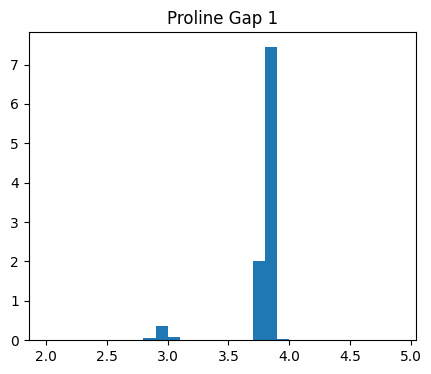

In [18]:
def cal_pro(chain_dict, atom_coor_dict, modres_dict, ca_dist_dict):
    keys = sorted(chain_dict[chain_id].keys())
    num_keys = len(keys)
    for i in range(num_keys):

        key = keys[i]
        res_name = chain_dict[chain_id][key]
        if res_name in modres_dict:
            res_name = modres_dict[res_name]

        res_dict = atom_coor_dict[chain_id][key]
        if ' CA ' in res_dict:
            pos_ca = res_dict[' CA ']
        else:
            continue
        for j in range(1,2):
            if i+j <= num_keys-1:
                key_j = keys[i+j]
            else:
                continue

            res_j_dict = atom_coor_dict[chain_id][key_j]
            res_j_name = chain_dict[chain_id][key_j]
            if res_j_name in modres_dict:
                res_j_name = modres_dict[res_j_name]
            if res_j_name != 'PRO':
                continue
            if ' CA ' in res_j_dict:
                pos_j_ca = res_j_dict[' CA ']
                dist = np.linalg.norm(pos_ca - pos_j_ca)
                ca_dist_dict[j] += [dist]

ca_dist_pro_dict = dict()
for j in range(1,2):
    ca_dist_pro_dict[j] = list()

num_pdb = len(pdb_list)
for i in range(0, num_pdb):
    pdb_id = pdb_list[i][0]
    chain_id = pdb_list[i][1]

    sub_dir = '%s/%s' % (data_dir, pdb_id[0])
    pdb_file = '%s/%s.pdb.gz' % (sub_dir, pdb_id)

    if not os.path.exists(pdb_file):
        continue

    chain_dict, atom_coor_dict, modres_dict = read_pdb(pdb_file)

    # 사슬 불일치(KeyError) 방지
    if chain_id not in chain_dict:
        continue

    cal_pro(chain_dict, atom_coor_dict, modres_dict, ca_dist_pro_dict)

plt.figure(figsize=(5, 4))
bins = np.arange(2,5,0.1)
plt.hist(ca_dist_pro_dict[1], bins, density=True)
plt.title("Proline Gap 1")
plt.show()

다음 잔기가 프롤린(Proline)일 때 한정하여 측정한 $i$와 $i+1$ 간의 거리입니다. "gap 1"와 비교했을 때, 3.8 Å(trans)의 주 봉우리 외에도 3.0 Å 부근의 작은 봉우리가 확연하게 커진 것을 볼 수 있습니다. 프롤린은 측쇄가 뼈대의 질소 원자와 결합해 둥근 고리를 형성하는 유일한 구조적 특징 때문에 cis 펩타이드 결합을 형성할 확률이 다른 아미노산보다 압도적으로 높습니다. 이 히스토그램은 그러한 프롤린 특유의 3.0 Å cis 결합 빈도 증가를 시각적으로 증명합니다.